# Factor AI Lab 02 — can a neural network improve a PDV velocity trace?

This notebook treats STFT design as an **evaluation problem**. It first searches window length, overlap, window function, and zero padding with a conventional peak-ridge estimator. It then gives a small CNN the same spectrogram information and a fixed training budget.

**Decision:** choose a processing configuration for recovering a non-negative line-of-sight speed magnitude from a real-valued synthetic PDV voltage trace.

**Boundary:** this is synthetic development evidence. It does not validate a real diagnostic, recover signed motion, identify melting, or distinguish ETI from MRTI.

## 0. Freeze the evaluation contract before looking at test results

- Input: one detector-voltage trace and known sampling rate and laser wavelength.
- Output: speed magnitude at each STFT frame center.
- Train: 32 independent synthetic shots. Development: 12 shots.
- Fresh locked test for this revision: independent matched and shifted shots with faster changes, dropout, and a secondary return. Earlier test seeds are retired after exposure.
- Baseline: strongest STFT ridge. Candidate: a small temporal CNN.
- Primary metrics: MAE, bias, RMSE, and 95th-percentile absolute error in m/s.
- Provisional acceptance gate: matched MAE ≤ 15 m/s, shifted MAE ≤ 40 m/s, and CNN matched MAE below the selected conventional baseline.

The thresholds are teaching values, not facility requirements. Zero padding samples the spectrum more densely; it does not create new measurement information.

In [1]:
from dataclasses import dataclass, asdict
from itertools import product
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import ShortTimeFFT
import torch
from torch import nn

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
FS = 4.0e9                 # samples/second
WAVELENGTH = 1550e-9       # meters
N_SAMPLES = 1024
MAX_SPEED = 1300.0         # m/s represented by the estimator
N_VELOCITY_BINS = 96
VELOCITY_GRID = np.linspace(0, MAX_SPEED, N_VELOCITY_BINS)
SAMPLE_TIME = np.arange(N_SAMPLES) / FS

print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | device {DEVICE}")
print(f"Trace: {N_SAMPLES} samples, {N_SAMPLES/FS*1e9:.1f} ns | Nyquist speed: {WAVELENGTH*FS/4:.1f} m/s")

Python 3.12.14 | PyTorch 2.14.0 | device mps
Trace: 1024 samples, 256.0 ns | Nyquist speed: 1550.0 m/s


## 1. Transparent synthetic forward model
For normal-incidence heterodyne PDV, speed magnitude and beat frequency follow `v = wavelength × frequency / 2`. We integrate frequency to make optical phase, then record a noisy cosine. The shifted family adds effects that training does not contain. Simulator labels are exact only inside this generator.

In [2]:
def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x*x*(3 - 2*x)

def simulate_shot(seed, family="matched"):
    rng = np.random.default_rng(seed)
    u = np.linspace(0, 1, N_SAMPLES)
    start = rng.uniform(80, 180)
    rise = rng.uniform(450, 760) * smoothstep((u-rng.uniform(.08,.22))/rng.uniform(.55,.8))
    ripple = rng.uniform(20, 75) * np.sin(2*np.pi*(rng.uniform(.7,1.8)*u + rng.random()))
    speed = np.clip(start + rise + ripple, 25, 1150)
    amplitude = 1 + .22*np.sin(2*np.pi*(rng.uniform(.4,1.3)*u+rng.random()))
    secondary = 0.0
    if family == "shifted":
        center = rng.uniform(.42,.7)
        speed += rng.uniform(120,260) * .5*(1+np.tanh((u-center)/rng.uniform(.012,.025)))
        speed = np.clip(speed, 25, MAX_SPEED)
        amplitude *= 1 - rng.uniform(.65,.95)*np.exp(-.5*((u-rng.uniform(.45,.75))/rng.uniform(.025,.06))**2)
        other_speed = np.clip(speed + rng.uniform(120,260), 0, MAX_SPEED)
        other_phase = 2*np.pi*np.cumsum(2*other_speed/WAVELENGTH)/FS + rng.uniform(0,2*np.pi)
        secondary = rng.uniform(.18,.4)*np.cos(other_phase)
    beat_frequency = 2*speed/WAVELENGTH
    phase = 2*np.pi*np.cumsum(beat_frequency)/FS + rng.uniform(0,2*np.pi)
    drift = rng.uniform(.05,.18)*np.sin(2*np.pi*rng.uniform(4e6,16e6)*SAMPLE_TIME+rng.random())
    noise = rng.normal(0, rng.uniform(.08,.2), N_SAMPLES)
    voltage = amplitude*np.cos(phase) + secondary + drift + noise
    return {"seed": seed, "family": family, "voltage": voltage.astype("float32"),
            "speed": speed.astype("float32")}

train_shots = [simulate_shot(1000+i) for i in range(32)]
dev_shots = [simulate_shot(2000+i) for i in range(12)]
# Seeds 3000–3011 and 4000–4011 were exposed during earlier notebook development.
# This revision gets a fresh, larger test set. Do not tune after viewing it.
TEST_SET_VERSION = "pdv-synthetic-v2-seeds-5000-6023"
test_matched = [simulate_shot(5000+i) for i in range(24)]
test_shifted = [simulate_shot(6000+i, "shifted") for i in range(24)]
print("Independent shot split:", len(train_shots), len(dev_shots), len(test_matched), len(test_shifted))
print("Locked test version:", TEST_SET_VERSION)

Independent shot split: 32 12 24 24
Locked test version: pdv-synthetic-v2-seeds-5000-6023


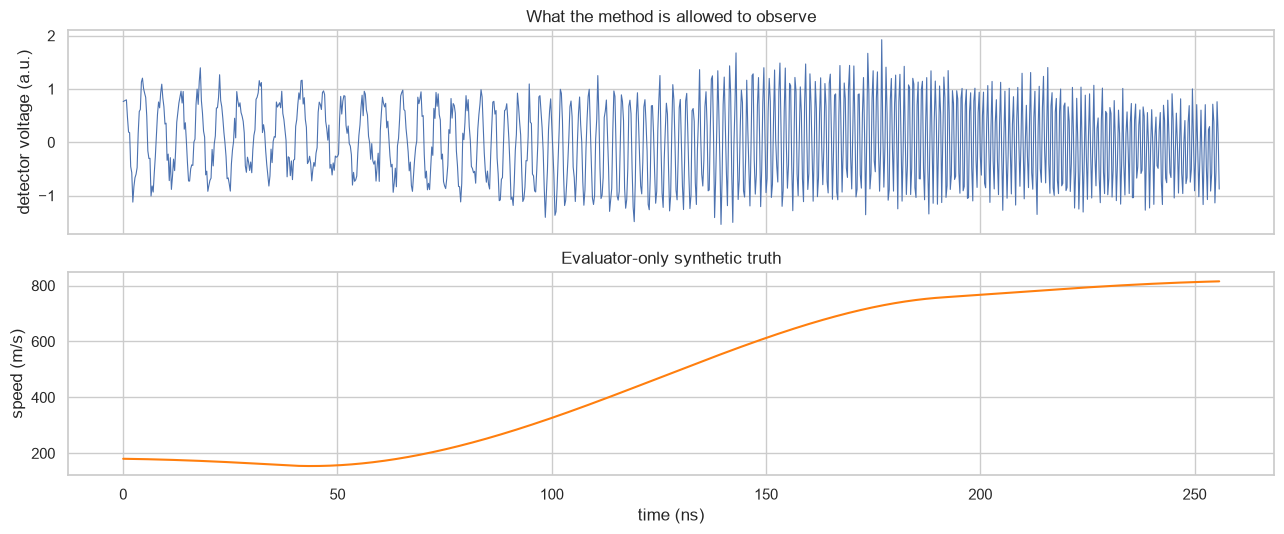

In [3]:
example = train_shots[0]
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(SAMPLE_TIME*1e9, example["voltage"], linewidth=.8)
axes[0].set(ylabel="detector voltage (a.u.)", title="What the method is allowed to observe")
axes[1].plot(SAMPLE_TIME*1e9, example["speed"], color="tab:orange")
axes[1].set(xlabel="time (ns)", ylabel="speed (m/s)", title="Evaluator-only synthetic truth")
plt.tight_layout(); plt.show()

## 2. STFT configurations and the conventional baseline
A long window improves frequency resolution but smears fast changes in time. More overlap produces more time samples and more computation. Window shape changes leakage. Zero padding gives a denser frequency grid without adding information.

In [4]:
@dataclass(frozen=True)
class STFTConfig:
    window_length: int
    overlap: float
    window: str
    zero_pad: int

CONFIGS = [STFTConfig(*values) for values in product(
    [24, 48, 96, 192], [.25, .50, .75], ["hann", "blackman"], [1, 2, 4, 8, 16])]

def transform(shot, config):
    noverlap = int(config.window_length * config.overlap)
    nfft = config.window_length * config.zero_pad
    stft = ShortTimeFFT.from_window(config.window, fs=FS, nperseg=config.window_length,
                                    noverlap=noverlap, mfft=nfft, scale_to="magnitude")
    magnitude = np.abs(stft.stft(shot["voltage"]))
    frame_time = stft.t(N_SAMPLES)
    inside = (frame_time >= 0) & (frame_time <= SAMPLE_TIME[-1])
    frame_time, magnitude = frame_time[inside], magnitude[:, inside]
    native_velocity = WAVELENGTH * stft.f / 2
    usable = native_velocity <= MAX_SPEED
    resized = np.stack([np.interp(VELOCITY_GRID, native_velocity[usable], magnitude[usable, j])
                        for j in range(magnitude.shape[1])], axis=1)
    db = 20*np.log10(resized/(resized.max()+1e-12)+1e-6)
    features = np.clip((db+60)/60, 0, 1).astype("float32")
    truth = np.interp(frame_time, SAMPLE_TIME, shot["speed"]).astype("float32")
    return features, truth, frame_time

def ridge_prediction(features):
    return VELOCITY_GRID[np.argmax(features, axis=0)]

def metrics(prediction, truth):
    error = np.concatenate(prediction) - np.concatenate(truth)
    return {"mae": np.mean(np.abs(error)), "bias": np.mean(error),
            "rmse": np.sqrt(np.mean(error**2)), "p95": np.percentile(np.abs(error),95)}

def score_ridge(config, shots):
    predictions, truths = [], []
    for shot in shots:
        features, truth, _ = transform(shot, config)
        predictions.append(ridge_prediction(features)); truths.append(truth)
    return metrics(predictions, truths)

started = time.perf_counter()
ridge_rows = []
for config in CONFIGS:
    score = score_ridge(config, dev_shots)
    hop = config.window_length - int(config.window_length*config.overlap)
    ridge_rows.append({**asdict(config), **score,
                       "window_duration_ns": config.window_length/FS*1e9,
                       "frame_spacing_ns": hop/FS*1e9,
                       "native_fft_spacing_ms": WAVELENGTH*FS/(2*config.window_length*config.zero_pad),
                       "output_grid_spacing_ms": VELOCITY_GRID[1]-VELOCITY_GRID[0]})
ridge_search = pd.DataFrame(ridge_rows).sort_values("mae").reset_index(drop=True)
print(f"Evaluated {len(CONFIGS)} configurations on development shots in {time.perf_counter()-started:.2f} s")
print(f"Actual estimator output-grid spacing: {VELOCITY_GRID[1]-VELOCITY_GRID[0]:.2f} m/s")
ridge_search.head(8).round(2)

Evaluated 120 configurations on development shots in 1.01 s
Actual estimator output-grid spacing: 13.68 m/s


,window_length,overlap,window,zero_pad,mae,bias,rmse,p95,window_duration_ns,frame_spacing_ns,native_fft_spacing_ms,output_grid_spacing_ms
0,96,0.75,hann,8,3.67,-0.09,4.54,7.41,24.0,6.0,4.04,13.68
1,96,0.75,hann,16,3.67,-0.06,4.55,7.41,24.0,6.0,2.02,13.68
2,96,0.75,blackman,8,3.67,-0.03,4.55,7.41,24.0,6.0,4.04,13.68
3,96,0.75,blackman,16,3.68,-0.03,4.56,7.46,24.0,6.0,2.02,13.68
4,96,0.75,hann,4,3.69,0.07,4.57,7.45,24.0,6.0,8.07,13.68
5,96,0.75,blackman,4,3.72,0.12,4.62,7.51,24.0,6.0,8.07,13.68
6,96,0.75,blackman,2,3.75,0.18,4.67,7.83,24.0,6.0,16.15,13.68
7,96,0.75,hann,2,3.75,0.07,4.67,7.88,24.0,6.0,16.15,13.68


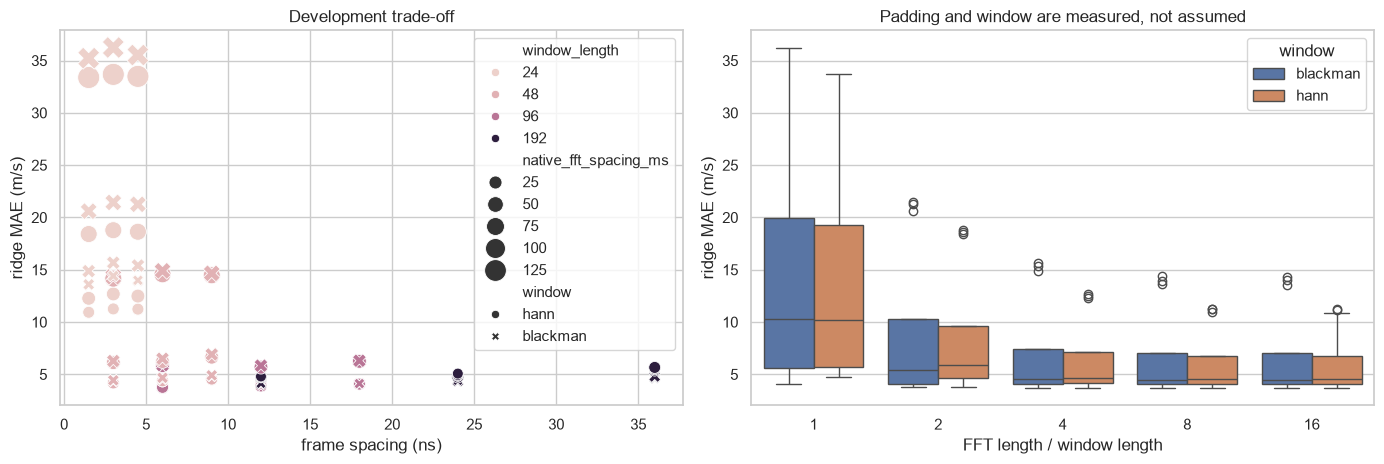

Selected conventional configuration from development data: STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=8)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.scatterplot(data=ridge_search, x="frame_spacing_ns", y="mae", size="native_fft_spacing_ms",
                hue="window_length", style="window", sizes=(50,250), ax=axes[0])
axes[0].set(title="Development trade-off", xlabel="frame spacing (ns)", ylabel="ridge MAE (m/s)")
sns.boxplot(data=ridge_search, x="zero_pad", y="mae", hue="window", ax=axes[1])
axes[1].set(title="Padding and window are measured, not assumed", xlabel="FFT length / window length", ylabel="ridge MAE (m/s)")
plt.tight_layout(); plt.show()

best_ridge_row = ridge_search.iloc[0]
BEST_RIDGE_CONFIG = STFTConfig(int(best_ridge_row.window_length), float(best_ridge_row.overlap),
                               str(best_ridge_row.window), int(best_ridge_row.zero_pad))
print("Selected conventional configuration from development data:", BEST_RIDGE_CONFIG)

## 3. Train the neural candidate
The CNN reads the normalized spectrogram and predicts one speed per STFT frame. The configurable budget selects candidates from the conventional development ranking. Every configuration uses the same initialization seed, architecture, maximum epochs, optimizer, and early-stopping rule. This is still a finite search over one CNN family, not a global neural optimum.

In [6]:
CNN_CONFIG_BUDGET = len(CONFIGS)  # evaluate all configurations requested above
CNN_EPOCHS = 3000                # maximum; early stopping may finish sooner
CNN_PATIENCE = 350
CNN_COMMON_SEED = 101

class VelocityCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(N_VELOCITY_BINS, 48, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(48, 24, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(24, 1, kernel_size=1), nn.Sigmoid())
    def forward(self, spectrogram):
        return self.network(spectrogram).squeeze(1) * MAX_SPEED

def batch_for(shots, config):
    transformed = [transform(shot, config) for shot in shots]
    return (torch.tensor(np.stack([item[0] for item in transformed]), device=DEVICE),
            torch.tensor(np.stack([item[1] for item in transformed]), device=DEVICE))

def train_cnn(config, seed=CNN_COMMON_SEED):
    torch.manual_seed(seed)
    train_features, train_truth = batch_for(train_shots, config)
    dev_features, dev_truth = batch_for(dev_shots, config)
    model = VelocityCNN().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    loss_function = nn.SmoothL1Loss(beta=15.0)
    learning, best = [], {"mae": float("inf"), "state": None, "epoch": 0}
    for epoch in range(1, CNN_EPOCHS+1):
        model.train(); optimizer.zero_grad()
        train_prediction = model(train_features)
        loss = loss_function(train_prediction, train_truth)
        loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            dev_mae = (model(dev_features)-dev_truth).abs().mean().item()
        learning.append({"epoch": epoch, "train_loss": loss.item(), "dev_mae": dev_mae})
        if dev_mae < best["mae"]:
            best = {"mae": dev_mae, "state": copy.deepcopy(model.state_dict()), "epoch": epoch}
        if epoch - best["epoch"] >= CNN_PATIENCE:
            break
    model.load_state_dict(best["state"]); model.eval()
    return model, pd.DataFrame(learning), best["mae"], epoch, best["epoch"]

candidate_configs = [STFTConfig(int(row.window_length), float(row.overlap), str(row.window), int(row.zero_pad))
                     for _, row in ridge_search.head(CNN_CONFIG_BUDGET).iterrows()]
cnn_runs = []
started = time.perf_counter()
for number, config in enumerate(candidate_configs, 1):
    model, learning, dev_mae, epochs_run, best_epoch = train_cnn(config)
    cnn_runs.append({"config": config, "model": model, "learning": learning, "dev_mae": dev_mae,
                     "epochs_run": epochs_run, "best_epoch": best_epoch})
    print(f"{number}/{len(candidate_configs)} {config} -> dev MAE {dev_mae:.2f} m/s "
          f"(best epoch {best_epoch}, stopped {epochs_run})")
print(f"CNN search budget: {len(candidate_configs)} configurations × {CNN_EPOCHS} epochs = {time.perf_counter()-started:.1f} s")

1/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=8) -> dev MAE 13.78 m/s (best epoch 2999, stopped 3000)


2/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=16) -> dev MAE 14.10 m/s (best epoch 2996, stopped 3000)


3/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=8) -> dev MAE 12.60 m/s (best epoch 2977, stopped 3000)


4/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=16) -> dev MAE 13.06 m/s (best epoch 2952, stopped 3000)


5/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=4) -> dev MAE 13.16 m/s (best epoch 2959, stopped 3000)


...

116/120 STFTConfig(window_length=24, overlap=0.25, window='hann', zero_pad=1) -> dev MAE 5.40 m/s (best epoch 2098, stopped 2448)


117/120 STFTConfig(window_length=24, overlap=0.5, window='hann', zero_pad=1) -> dev MAE 4.07 m/s (best epoch 2848, stopped 3000)


118/120 STFTConfig(window_length=24, overlap=0.75, window='blackman', zero_pad=1) -> dev MAE 2.64 m/s (best epoch 2915, stopped 3000)


119/120 STFTConfig(window_length=24, overlap=0.25, window='blackman', zero_pad=1) -> dev MAE 6.26 m/s (best epoch 846, stopped 1196)


120/120 STFTConfig(window_length=24, overlap=0.5, window='blackman', zero_pad=1) -> dev MAE 5.45 m/s (best epoch 2404, stopped 2754)
CNN search budget: 120 configurations × 3000 epochs = 438.0 s


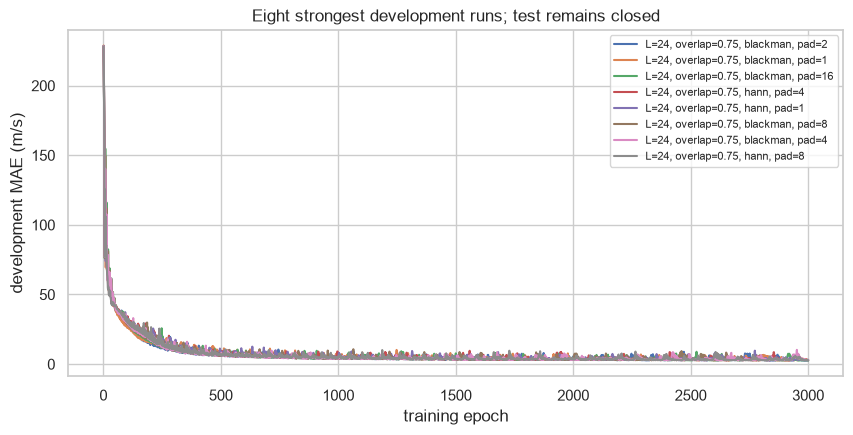

Selected neural configuration: STFTConfig(window_length=24, overlap=0.75, window='blackman', zero_pad=2) development MAE=2.58 m/s
All configurations used the same initialization seed: 101


In [7]:
fig, ax = plt.subplots(figsize=(10,4.5))
for run in sorted(cnn_runs, key=lambda item: item["dev_mae"])[:8]:
    label = f"L={run['config'].window_length}, overlap={run['config'].overlap}, {run['config'].window}, pad={run['config'].zero_pad}"
    ax.plot(run["learning"].epoch, run["learning"].dev_mae, label=label)
ax.set(xlabel="training epoch", ylabel="development MAE (m/s)", title="Eight strongest development runs; test remains closed")
ax.legend(fontsize=8); plt.show()
best_cnn = min(cnn_runs, key=lambda run: run["dev_mae"])
print("Selected neural configuration:", best_cnn["config"], f"development MAE={best_cnn['dev_mae']:.2f} m/s")
print("All configurations used the same initialization seed:", CNN_COMMON_SEED)

## 4. Open this revision's fresh locked test once
Earlier test seeds were exposed during development and have been retired. Matched tests ask whether the method generalizes to new draws from the training family. Shifted tests ask whether it survives faster acceleration, lost optical return, and a second return. We report both instead of averaging away failure. Any tuning after viewing the following results requires another test-set version.

In [8]:
def cnn_predictions(model, config, shots):
    features, truth = batch_for(shots, config)
    with torch.no_grad(): prediction = model(features).cpu().numpy()
    return [row for row in prediction], [row for row in truth.cpu().numpy()]

test_rows = []
for regime, shots in [("matched", test_matched), ("shifted", test_shifted)]:
    ridge_prediction_list, ridge_truth = [], []
    for shot in shots:
        features, truth, _ = transform(shot, BEST_RIDGE_CONFIG)
        ridge_prediction_list.append(ridge_prediction(features)); ridge_truth.append(truth)
    test_rows.append({"method": "STFT ridge", "regime": regime, **metrics(ridge_prediction_list, ridge_truth)})
    pred, truth = cnn_predictions(best_cnn["model"], best_cnn["config"], shots)
    test_rows.append({"method": "STFT + CNN", "regime": regime, **metrics(pred, truth)})
test_results = pd.DataFrame(test_rows)
test_results.round(2)

,method,regime,mae,bias,rmse,p95
0,STFT ridge,matched,3.56,0.20,4.48,6.95
1,STFT + CNN,matched,2.99,-0.41,9.34,6.91
2,STFT ridge,shifted,10.49,1.08,49.33,15.99
3,STFT + CNN,shifted,70.94,-42.67,177.59,486.00


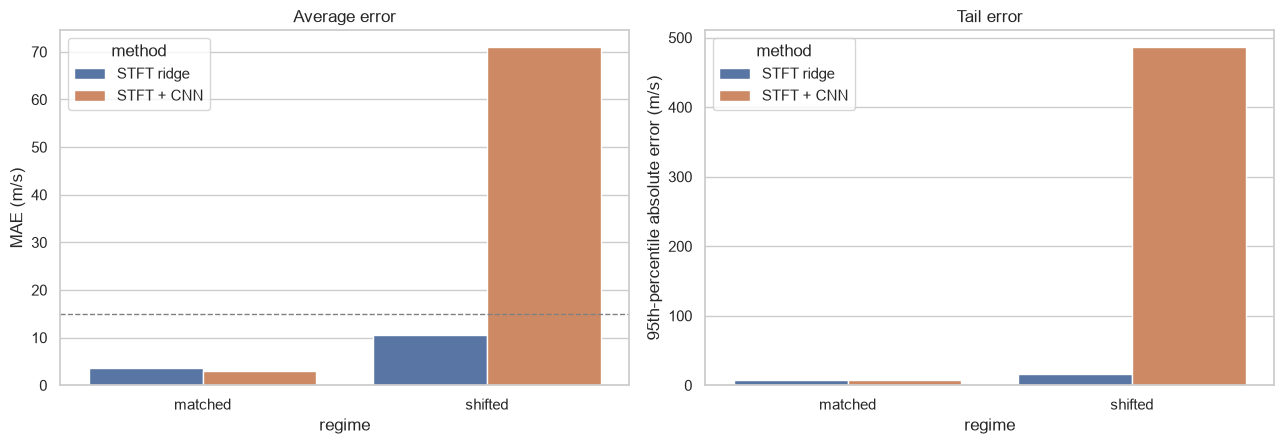

PROVISIONAL GATE: FAIL
Matched improvement versus ridge: 0.57 m/s
A failed gate is useful: it tells us the neural method or the available signal needs a specific change.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.6))
sns.barplot(data=test_results, x="regime", y="mae", hue="method", ax=axes[0])
axes[0].axhline(15, color="gray", linestyle="--", linewidth=1, label="matched gate")
axes[0].set(title="Average error", ylabel="MAE (m/s)")
sns.barplot(data=test_results, x="regime", y="p95", hue="method", ax=axes[1])
axes[1].set(title="Tail error", ylabel="95th-percentile absolute error (m/s)")
plt.tight_layout(); plt.show()

cnn_matched = test_results.query("method == 'STFT + CNN' and regime == 'matched'").iloc[0]
cnn_shifted = test_results.query("method == 'STFT + CNN' and regime == 'shifted'").iloc[0]
ridge_matched = test_results.query("method == 'STFT ridge' and regime == 'matched'").iloc[0]
accepted = cnn_matched.mae <= 15 and cnn_shifted.mae <= 40 and cnn_matched.mae < ridge_matched.mae
print("PROVISIONAL GATE:", "PASS" if accepted else "FAIL")
print(f"Matched improvement versus ridge: {ridge_matched.mae-cnn_matched.mae:.2f} m/s")
if accepted:
    print("The candidate passed these provisional synthetic criteria; real-data validation is still required.")
else:
    print("A failed gate is useful: it tells us the neural method or the available signal needs a specific change.")

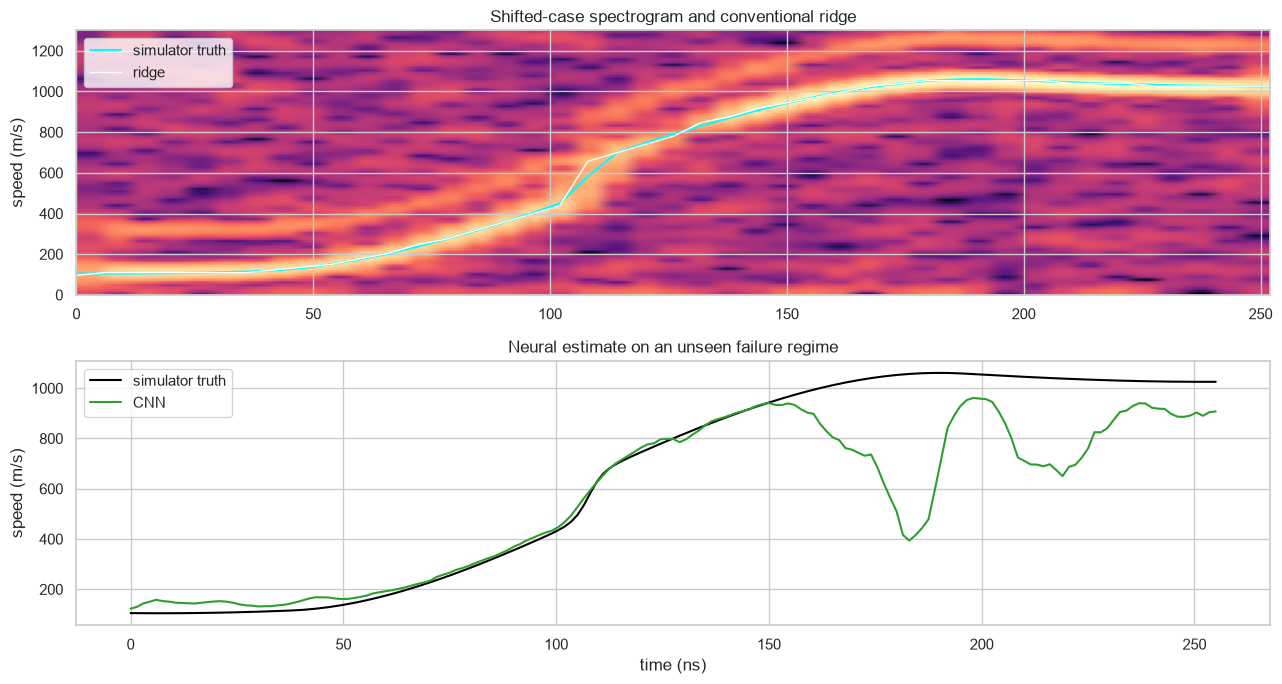

In [10]:
# Inspect one difficult shifted shot instead of trusting only aggregate scores.
shot = test_shifted[0]
ridge_features, ridge_truth, ridge_time = transform(shot, BEST_RIDGE_CONFIG)
ridge_trace = ridge_prediction(ridge_features)
cnn_features, cnn_truth, cnn_time = transform(shot, best_cnn["config"])
with torch.no_grad():
    cnn_trace = best_cnn["model"](torch.tensor(cnn_features[None], device=DEVICE)).cpu().numpy()[0]
fig, axes = plt.subplots(2,1,figsize=(13,7),sharex=False)
axes[0].imshow(ridge_features, origin="lower", aspect="auto",
               extent=[ridge_time[0]*1e9,ridge_time[-1]*1e9,0,MAX_SPEED], cmap="magma")
axes[0].plot(ridge_time*1e9, ridge_truth, color="cyan", label="simulator truth")
axes[0].plot(ridge_time*1e9, ridge_trace, color="white", linewidth=1, label="ridge")
axes[0].set(ylabel="speed (m/s)", title="Shifted-case spectrogram and conventional ridge"); axes[0].legend()
axes[1].plot(cnn_time*1e9, cnn_truth, color="black", label="simulator truth")
axes[1].plot(cnn_time*1e9, cnn_trace, color="tab:green", label="CNN")
axes[1].set(xlabel="time (ns)", ylabel="speed (m/s)", title="Neural estimate on an unseen failure regime"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. What this result can and cannot decide

This notebook can compare processing choices **within its synthetic contract**. It cannot tell us the best settings for Mykonos or MagLIF data until we supply the real sampling rate, wavelength, bandwidth, noise, optical-return behavior, calibration, timing convention, and an independent reference or uncertainty model.

The most useful next input is one de-identified raw PDV waveform with its sample interval, laser wavelength, trigger reference, front-end bandwidth, and the existing analyst reconstruction. That is enough to test whether the synthetic nuisance model resembles reality without claiming the analyst trace is perfect truth.

## Experiments for you
1. Reduce `CNN_CONFIG_BUDGET` to 12 and compare the time saved with the selected result.
2. Add a Tukey window to `CONFIGS`. Freeze a new test-set version before judging it.
3. Remove zero padding. Compare native FFT spacing, fixed output-grid spacing, and actual error.
4. Make the velocity change twice as fast. Which window duration wins?
5. Add a second return to training. Does shifted performance improve, and does matched performance regress?
6. Repeat the winning configuration with several initialization seeds. Report mean, spread, and worst run.
7. Add an abstention output for low optical return and score false confidence.